# Simple Optimization — lifetime_us + velocity_cm_us

Jointly optimizes two physics parameters using gradient descent.

**Setup**
- Ground truth: `lifetime_us = 10 000 μs`, `velocity_cm_us = 0.160 cm/μs`
- 10 random starting points drawn from N(GT, 20% σ)
- 3 optimizers: SGD, Adam, AdamW (implemented in JAX, no optax needed)

**Gradient source**: `simulator.forward()` (differentiable path, requires `differentiable=True`).  
Gradients flow through drift, attenuation, and wire-response convolution.

**Main result**: 2D trajectory plot in (lifetime_us, velocity_cm_us) space showing
how each optimizer converges from noisy starts toward the GT.


In [ ]:
# =============================================================================
# CONFIGURATION — edit here
# =============================================================================

# Ground-truth parameter values
GT_LIFETIME_US    = 10_000.0   # μs
GT_VELOCITY_CM_US = 0.160      # cm/μs

# Starting-point noise
NOISE_FRAC = 0.20   # 20% Gaussian σ around GT
N_TRIES    = 10     # independent random starts
SEED       = 42

# Optimisation
N_STEPS    = 200     # steps per run

# Learning rates  (normalised parameter space: both params ≈ 1 at GT)
LR_SGD    = 0.01
LR_ADAM   = 0.05
LR_ADAMW  = 0.05
WD_ADAMW  = 0.002

# Gradient clipping (in normalised space)
MAX_GRAD_NORM = 1.0

# Parameter bounds (normalised: 1.0 = GT value)
PARAM_LO_N = 0.1
PARAM_HI_N = 4.0

# Sobolev loss padding per side (screening length L = max_pad/2 pixels).
# Default 1024 creates FFTs >4k×4k — too large for cuFFT scratch on this GPU.
# 128 → L=64 px, still gives strong directional gradients within ±20% noise.
SOBOLEV_MAX_PAD = 128

# Simulator
CONFIG_PATH        = 'config/cubic_wireplane_config.yaml'
DATA_PATH          = 'muon.h5'
EVENT_IDX          = 0
MAX_ACTIVE_BUCKETS = 1000

# n_segments controls the vmap/loop size in the differentiable backward pass.
# Must be >= n_actual deposits (5 335 here). Much smaller than TOTAL_PAD=200k
# is fine — the rest is zero-padded and doesn't affect the signal.
N_SEGMENTS = 10_000

In [ ]:
import gc
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import jax
import jax.numpy as jnp

from tools.simulation import DetectorSimulator
from tools.geometry import generate_detector
from tools.loader import load_event
from tools.losses import sobolev_loss_single, make_sobolev_weight

import os
os.makedirs('plots', exist_ok=True)

print(f'JAX version: {jax.__version__}')
print(f'JAX devices: {jax.devices()}')


JAX version: 0.9.2
JAX devices: [CudaDevice(id=0)]


E0408 17:32:15.819677   65388 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0408 17:32:15.831645   65309 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


In [ ]:
# =============================================================================
# BUILD DIFFERENTIABLE SIMULATOR
# differentiable=True + n_segments enables simulator.forward() and jax.grad.
# When differentiable=True, total_pad and response_chunk_size are both
# overridden to n_segments — keep n_segments small to avoid OOM in backward.
# =============================================================================

detector_config = generate_detector(CONFIG_PATH)
jax.clear_caches()
gc.collect()

simulator = DetectorSimulator(
    detector_config,
    differentiable=True,
    n_segments=N_SEGMENTS,
    use_bucketed=True,
    max_active_buckets=MAX_ACTIVE_BUCKETS,
    include_noise=False,
    include_electronics=False,
    include_track_hits=False,
    include_digitize=False,     # rounding/clipping breaks gradients
    track_config=None,
)
cfg = simulator.config

deposits = load_event(DATA_PATH, cfg, event_idx=EVENT_IDX)
n_total  = sum(v.n_actual for v in deposits.volumes)
print(f'Loaded {n_total:,} deposits  (n_segments={N_SEGMENTS})')

--- Creating DetectorSimulator ---
   Extracting parameters...
   Loading response kernels...
   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=10,000, response_chunk=10,000, num_s=16, K_wire=2, K_time=6
   Track labeling: DISABLED
   Readout: wire
   Volumes: 2 (iterate=scan)
--- DetectorSimulator Ready ---
Loaded 5,335 deposits  (n_segments=10000)


In [ ]:
# =============================================================================
# WARM UP  (compiles production JIT — ~60-90 s)
# =============================================================================

print('Warming up...')
t0 = time.time()
simulator.warm_up()
print(f'Done ({time.time()-t0:.1f}s)')


Warming up...
Triggering JIT compilation...
JIT compilation finished (total_pad=10,000, iterate=scan).
Done (5.4s)


In [ ]:
# =============================================================================
# GROUND-TRUTH SIGNAL + LOSS FUNCTION
# =============================================================================

base_params = simulator.default_sim_params

gt_params = base_params._replace(
    lifetime_us    = jnp.array(GT_LIFETIME_US),
    velocity_cm_us = jnp.array(GT_VELOCITY_CM_US),
)

print('Computing GT forward pass...')
t0 = time.time()
gt_arrays = simulator.forward(gt_params, deposits)
jax.block_until_ready(gt_arrays)
print(f'Done ({time.time()-t0:.1f}s)  —  {len(gt_arrays)} plane arrays')

# Per-plane Sobolev weights with reduced max_pad to avoid cuFFT OOM.
# max_pad=128 → padded FFT size ≈ (H+256)×(W+256), screening length L=64 px.
weights = tuple(
    make_sobolev_weight(arr.shape[0], arr.shape[1], max_pad=SOBOLEV_MAX_PAD)
    for arr in gt_arrays
)
print(f'Sobolev weights: max_pad={SOBOLEV_MAX_PAD}, '
      f'FFT sizes: {[w.shape for w in weights]}')

def unpack(params_n):
    return params_n[0] * GT_LIFETIME_US, params_n[1] * GT_VELOCITY_CM_US

def loss_fn(params_n):
    lt, vel = unpack(params_n)
    p = gt_params._replace(lifetime_us=lt, velocity_cm_us=vel)
    pred = simulator.forward(p, deposits)
    return jnp.sum(jnp.array([
        sobolev_loss_single(pr, gt, w)
        for pr, gt, w in zip(pred, gt_arrays, weights)
    ]))

print(f'Loss at GT (should be ~0): {loss_fn(jnp.array([1.0, 1.0])):.3e}')

Computing GT forward pass...
Done (5.6s)  —  6 plane arrays
Sobolev weights: max_pad=128, FFT sizes: [(2225, 2957), (2225, 2957), (2225, 2957), (2225, 2957), (2225, 2957), (2225, 2957)]
Loss at GT (should be ~0): 5.408e-12


In [ ]:
# =============================================================================
# OPTIMISERS  (pure JAX, no optax)
# All operate on a flat jnp.ndarray of shape (2,).
# State dicts use plain Python (not jnp) for the step counter to avoid tracing.
# =============================================================================

# ── SGD ───────────────────────────────────────────────────────────────────────
def sgd_init(p):
    return {}

def sgd_step(p, g, state):
    return p - LR_SGD * g, state

# ── Adam ──────────────────────────────────────────────────────────────────────
_B1, _B2, _EPS = 0.9, 0.999, 1e-8

def adam_init(p):
    return dict(m=jnp.zeros(2), v=jnp.zeros(2), t=0)

def adam_step(p, g, state, lr=LR_ADAM):
    t = state['t'] + 1
    m = _B1 * state['m'] + (1 - _B1) * g
    v = _B2 * state['v'] + (1 - _B2) * g ** 2
    m_hat = m / (1 - _B1 ** t)
    v_hat = v / (1 - _B2 ** t)
    return p - lr * m_hat / (jnp.sqrt(v_hat) + _EPS), dict(m=m, v=v, t=t)

# ── AdamW ─────────────────────────────────────────────────────────────────────
def adamw_init(p):
    return dict(m=jnp.zeros(2), v=jnp.zeros(2), t=0)

def adamw_step(p, g, state):
    t = state['t'] + 1
    m = _B1 * state['m'] + (1 - _B1) * g
    v = _B2 * state['v'] + (1 - _B2) * g ** 2
    m_hat = m / (1 - _B1 ** t)
    v_hat = v / (1 - _B2 ** t)
    # weight decay applied to params directly (decoupled, toward 0)
    new_p = p - LR_ADAMW * (m_hat / (jnp.sqrt(v_hat) + _EPS) + WD_ADAMW * p)
    return new_p, dict(m=m, v=v, t=t)

OPTIMISERS = {
    #'SGD':   (sgd_init,   sgd_step),
    'Adam':  (adam_init,  adam_step),
    'AdamW': (adamw_init, adamw_step),
}
print('Optimisers ready:', list(OPTIMISERS))


Optimisers ready: ['SGD', 'Adam', 'AdamW']


In [ ]:
# =============================================================================
# JIT-COMPILE GRADIENT FUNCTION
# First call traces + compiles the differentiable path — may take 1-3 min.
# =============================================================================

loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))

print('Compiling gradient (first call)...')
t0 = time.time()
_lv, _gv = loss_and_grad(jnp.array([1.0, 1.0]))
jax.block_until_ready((_lv, _gv))
print(f'Done ({time.time()-t0:.1f}s)')
print(f'  loss at GT = {float(_lv):.3e}')
print(f'  grad at GT = {np.array(_gv)}  (should be ~0)')


Compiling gradient (first call)...
Done (29.5s)
  loss at GT = 3.511e-12
  grad at GT = [ 0.00011696 -0.02023805]  (should be ~0)


In [ ]:
# =============================================================================
# GENERATE STARTING POINTS
# =============================================================================

rng = np.random.RandomState(SEED)
starts_n = []   # list of (lt_norm, vel_norm) starting points

for _ in range(N_TRIES):
    lt_n  = 1.0 + rng.randn() * NOISE_FRAC
    vel_n = 1.0 + rng.randn() * NOISE_FRAC
    starts_n.append((float(lt_n), float(vel_n)))

print(f'{N_TRIES} starting points (normalised, GT = 1.0):')
for i, (lt, vel) in enumerate(starts_n):
    print(f'  {i+1:2d}: lifetime={lt*GT_LIFETIME_US:.0f} μs  '
          f'velocity={vel*GT_VELOCITY_CM_US:.4f} cm/μs')


10 starting points (normalised, GT = 1.0):
   1: lifetime=10993 μs  velocity=0.1556 cm/μs
   2: lifetime=11295 μs  velocity=0.2087 cm/μs
   3: lifetime=9532 μs  velocity=0.1525 cm/μs
   4: lifetime=13158 μs  velocity=0.1846 cm/μs
   5: lifetime=9061 μs  velocity=0.1774 cm/μs
   6: lifetime=9073 μs  velocity=0.1451 cm/μs
   7: lifetime=10484 μs  velocity=0.0988 cm/μs
   8: lifetime=6550 μs  velocity=0.1420 cm/μs
   9: lifetime=7974 μs  velocity=0.1701 cm/μs
  10: lifetime=8184 μs  velocity=0.1148 cm/μs


In [ ]:
# =============================================================================
# RUN OPTIMISATION  (10 tries × 3 optimisers)
# =============================================================================

# all_results[opt_name] = list of trajectories
# each trajectory = list of (lifetime_us, velocity_cm_us, loss) per step
all_results = {}

for opt_name, (init_fn, step_fn) in OPTIMISERS.items():
    print(f'\n=== {opt_name} ===')
    trajs = []

    for i, (lt0_n, vel0_n) in enumerate(starts_n):
        p = jnp.array([lt0_n, vel0_n])
        state = init_fn(p)

        lt0, vel0 = unpack(p)
        traj = [(float(lt0), float(vel0), float('nan'))]

        for s in range(N_STEPS):
            loss_val, grads = loss_and_grad(p)

            # Gradient norm clipping (in normalised space)
            gnorm = jnp.linalg.norm(grads)
            grads = jnp.where(gnorm > MAX_GRAD_NORM,
                              grads * (MAX_GRAD_NORM / gnorm),
                              grads)

            p, state = step_fn(p, grads, state)

            # Clamp parameters to valid range
            p = jnp.clip(p, PARAM_LO_N, PARAM_HI_N)

            lt, vel = unpack(p)
            traj.append((float(lt), float(vel), float(loss_val)))

        loss_final, _ = loss_and_grad(p)
        lt, vel = unpack(p)
        traj.append((float(lt), float(vel), float(loss_final)))

        trajs.append(traj)
        print(f'  try {i+1:2d}: '
              f'start=({lt0:.0f} μs, {vel0:.4f} cm/μs)  →  '
              f'end=({float(lt):.0f} μs, {float(vel):.4f} cm/μs)  '
              f'loss={float(loss_final):.3e}')

    all_results[opt_name] = trajs

print('\nDone.')

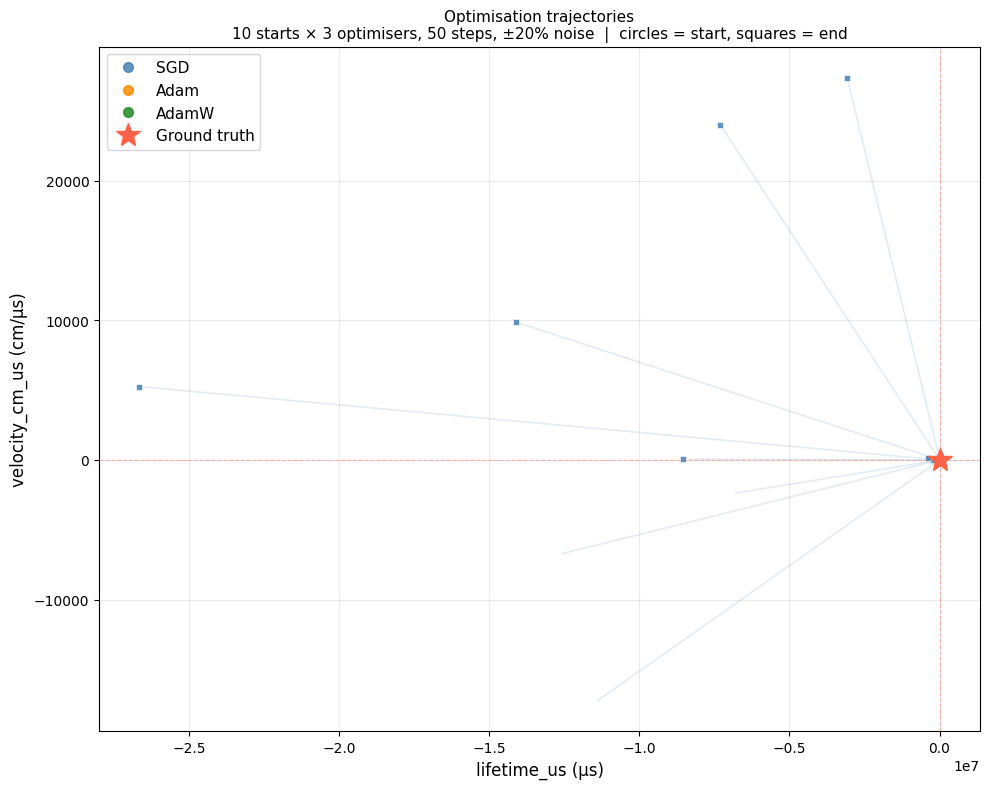

In [ ]:
# =============================================================================
# PLOT: 2D TRAJECTORIES IN (lifetime_us, velocity_cm_us) SPACE
# =============================================================================

OPT_COLORS = {'SGD': 'steelblue', 'Adam': 'darkorange', 'AdamW': 'forestgreen'}

fig, ax = plt.subplots(figsize=(10, 8))

for opt_name, trajs in all_results.items():
    color = OPT_COLORS[opt_name]
    for i, traj in enumerate(trajs):
        lts  = [p[0] for p in traj]
        vels = [p[1] for p in traj]
        losses = [p[2] for p in traj[1:]]  # step 0 has nan

        # Colour trajectory by step number (dark = early, light = late)
        n = len(lts) - 1
        for s in range(n):
            alpha = 0.15 + 0.55 * (s / max(n - 1, 1))
            ax.plot(lts[s:s+2], vels[s:s+2], '-', color=color, alpha=alpha, lw=1.2)

        # Start marker
        ax.plot(lts[0], vels[0], 'o', color=color, ms=7, alpha=0.85,
                label=opt_name if i == 0 else None)
        # End marker
        ax.plot(lts[-1], vels[-1], 's', color=color, ms=5, alpha=0.85,
                markeredgecolor='white', markeredgewidth=0.5)

# Ground-truth marker
ax.plot(GT_LIFETIME_US, GT_VELOCITY_CM_US, '*', color='tomato',
        ms=18, zorder=6, label='Ground truth')

# Dashed lines through GT
ax.axvline(GT_LIFETIME_US, color='tomato', ls='--', lw=0.8, alpha=0.4)
ax.axhline(GT_VELOCITY_CM_US, color='tomato', ls='--', lw=0.8, alpha=0.4)

ax.set_xlabel('lifetime_us (μs)', fontsize=12)
ax.set_ylabel('velocity_cm_us (cm/μs)', fontsize=12)
ax.set_title(
    f'Optimisation trajectories\n'
    f'{N_TRIES} starts × 3 optimisers, {N_STEPS} steps, ±{int(NOISE_FRAC*100)}% noise  |  '
    f'circles = start, squares = end',
    fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
fig.savefig('plots/optimization_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()


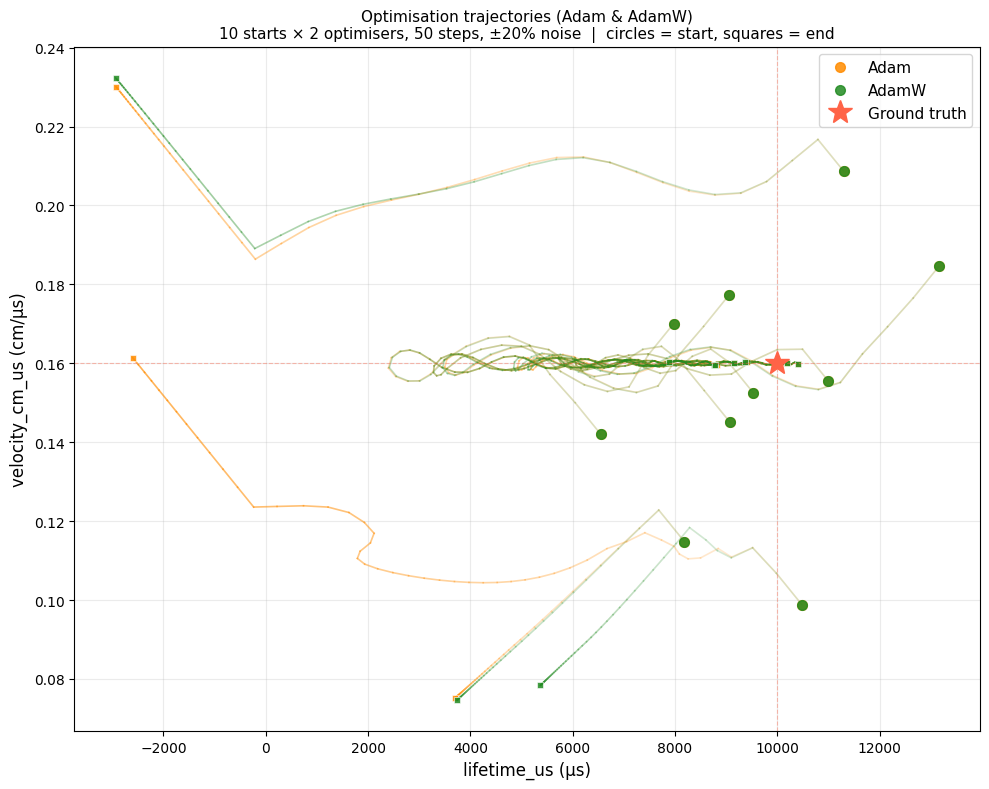

In [ ]:
# =============================================================================
# PLOT: 2D TRAJECTORIES IN (lifetime_us, velocity_cm_us) SPACE  — Adam & AdamW only
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

for opt_name, trajs in all_results.items():
    if opt_name == 'SGD':
        continue
    color = OPT_COLORS[opt_name]
    for i, traj in enumerate(trajs):
        lts  = [p[0] for p in traj]
        vels = [p[1] for p in traj]

        n = len(lts) - 1
        for s in range(n):
            alpha = 0.15 + 0.55 * (s / max(n - 1, 1))
            ax.plot(lts[s:s+2], vels[s:s+2], '-', color=color, alpha=alpha, lw=1.2)

        ax.plot(lts[0], vels[0], 'o', color=color, ms=7, alpha=0.85,
                label=opt_name if i == 0 else None)
        ax.plot(lts[-1], vels[-1], 's', color=color, ms=5, alpha=0.85,
                markeredgecolor='white', markeredgewidth=0.5)

ax.plot(GT_LIFETIME_US, GT_VELOCITY_CM_US, '*', color='tomato',
        ms=18, zorder=6, label='Ground truth')
ax.axvline(GT_LIFETIME_US, color='tomato', ls='--', lw=0.8, alpha=0.4)
ax.axhline(GT_VELOCITY_CM_US, color='tomato', ls='--', lw=0.8, alpha=0.4)

ax.set_xlabel('lifetime_us (μs)', fontsize=12)
ax.set_ylabel('velocity_cm_us (cm/μs)', fontsize=12)
ax.set_title(
    f'Optimisation trajectories (Adam & AdamW)\n'
    f'{N_TRIES} starts × 2 optimisers, {N_STEPS} steps, ±{int(NOISE_FRAC*100)}% noise  |  '
    f'circles = start, squares = end',
    fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
fig.savefig('plots/optimization_trajectories_no_sgd.png', dpi=150, bbox_inches='tight')
plt.show()

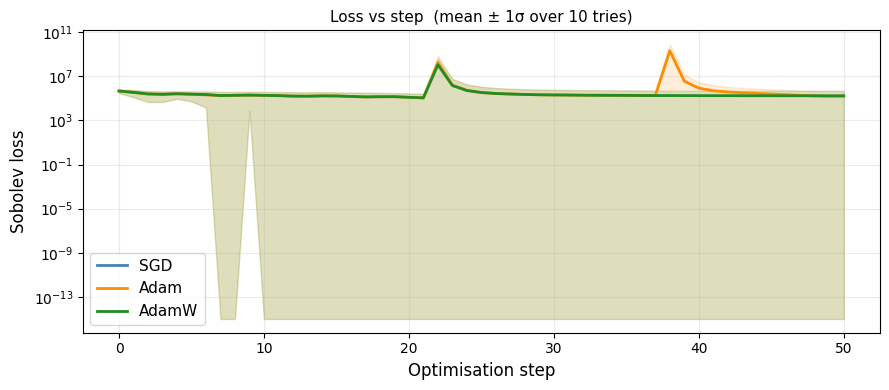

In [ ]:
# =============================================================================
# PLOT: LOSS CURVES  (mean ± std over 10 tries, per optimiser)
# =============================================================================

fig, ax = plt.subplots(figsize=(9, 4))
steps = np.arange(N_STEPS + 1)

for opt_name, trajs in all_results.items():
    color = OPT_COLORS[opt_name]
    # loss per step per try  (skip step 0 which has nan)
    loss_matrix = np.array([[p[2] for p in traj[1:]] for traj in trajs])  # (N_TRIES, N_STEPS+1)
    mean = np.mean(loss_matrix, axis=0)
    std  = np.std(loss_matrix, axis=0)
    ax.semilogy(steps, mean, color=color, lw=2, label=opt_name)
    ax.fill_between(steps, np.maximum(mean - std, 1e-15), mean + std,
                    color=color, alpha=0.15)

ax.set_xlabel('Optimisation step', fontsize=12)
ax.set_ylabel('Sobolev loss', fontsize=12)
ax.set_title(f'Loss vs step  (mean ± 1σ over {N_TRIES} tries)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25, which='both')
plt.tight_layout()
fig.savefig('plots/optimization_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
